# Classifying crystal structure from electron diffraction

This notebook goes from one simulated diffraction pattern to a scored classifier, with a picture at every step. Everything is synthetic and the labels are exact. It trains small models inline, so it runs end to end in a couple of minutes on a CPU.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from crystalclass.sim import SimConfig, simulate, LABELS
print('structure types:', LABELS)

structure types: ('sc', 'bcc', 'fcc', 'diamond', 'rocksalt', 'hcp')


## 1. One pattern, and the physics behind it

A zone-axis pattern is the set of reflections in the plane perpendicular to the beam. Which reflections survive is set by the structure factor, so the systematic absences that separate the lattices are built in. Here is a clean FCC pattern and its radial profile.

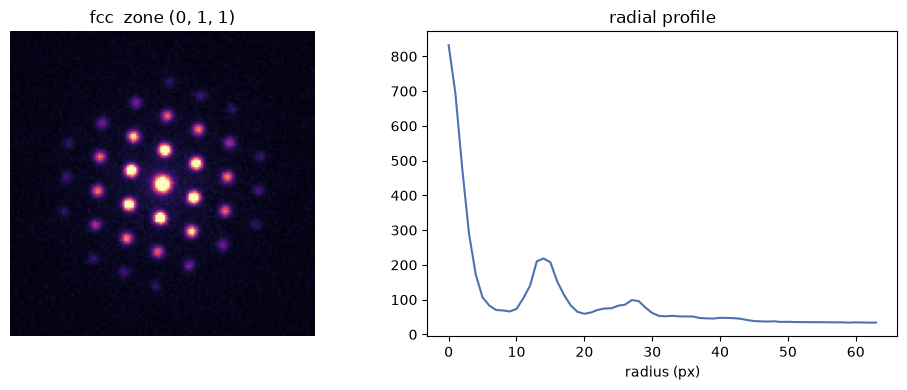

In [2]:
p = simulate(SimConfig(structure='fcc', dose=800, orientation_spread=0.0), np.random.default_rng(0))
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(p.image, cmap='magma', vmax=np.percentile(p.image, 99.5))
ax[0].set_title(f'{p.label}  zone {p.meta["zone_axis"]}'); ax[0].axis('off')
ax[1].plot(p.profile, color='#4c72b0'); ax[1].set_xlabel('radius (px)'); ax[1].set_title('radial profile')
plt.tight_layout(); plt.show()

## 2. The six structure types

Simple cubic, BCC, FCC, diamond, rock salt, and HCP. Diamond and rock salt share the FCC ring skeleton and are the hard confusions; HCP is the easy hexagonal one.

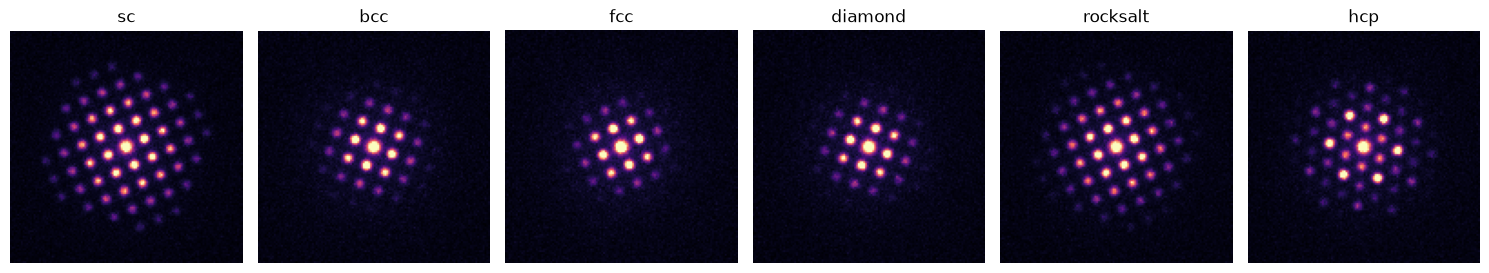

In [3]:
fig, axes = plt.subplots(1, 6, figsize=(15, 2.8))
for ax, name in zip(axes, LABELS):
    q = simulate(SimConfig(structure=name, dose=400, orientation_spread=0.0), np.random.default_rng(3))
    ax.imshow(q.image, cmap='magma', vmax=np.percentile(q.image, 99.5)); ax.axis('off'); ax.set_title(name)
plt.tight_layout(); plt.show()

## 3. What makes it hard: dose, orientation, missing reflections

The same FCC crystal under falling dose, then a tilt off the zone axis, then with most reflections dropped. These are the three axes the benchmark sweeps.

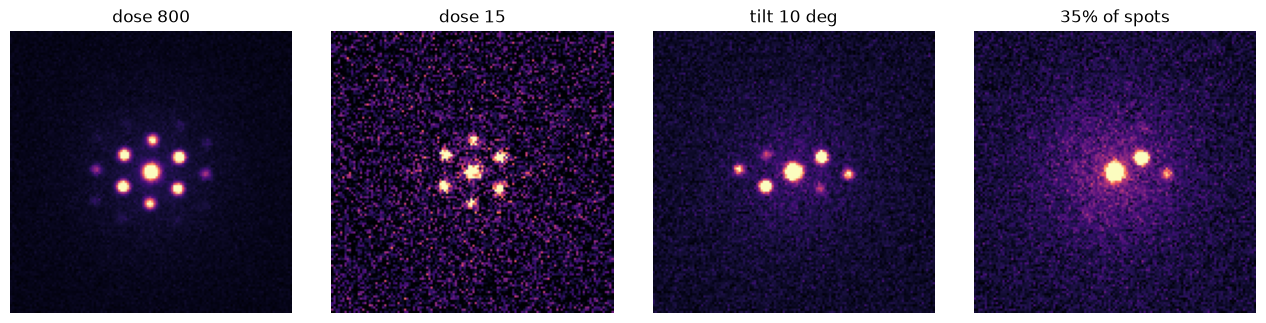

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
settings = [dict(dose=800), dict(dose=15), dict(dose=200, orientation_spread=10.0), dict(dose=200, keep_fraction=0.35)]
titles = ['dose 800', 'dose 15', 'tilt 10 deg', '35% of spots']
for ax, s, t in zip(axes, settings, titles):
    q = simulate(SimConfig(structure='fcc', **s), np.random.default_rng(1))
    ax.imshow(q.image, cmap='magma', vmax=np.percentile(q.image, 99.5)); ax.axis('off'); ax.set_title(t)
plt.tight_layout(); plt.show()

## 4. Build seeded datasets

A domain-randomised training pool and a class-balanced test set.

In [5]:
from crystalclass.datasets import make_training_dataset, make_dataset
from crystalclass.benchmark import reference_config
train = make_training_dataset(1200, seed=0)
test = make_dataset(len(LABELS) * 40, seed=99, base=reference_config({'dose': 40.0, 'orientation_spread': 3.0}))
print('train', train.images.shape, 'test', test.images.shape)

train (1200, 128, 128) test (240, 128, 128)


## 5. Classical baseline and the two CNNs

The classical model reads scale- and rotation-invariant ring features into a fair-tuned random forest. The 1D CNN sees the radial profile; the 2D CNN sees the whole pattern.

In [6]:
from crystalclass.classical import train_classical
from crystalclass.train import TrainSettings, train_model
from crystalclass.net import predict_pattern, predict_radial
from crystalclass.metrics import accuracy, summarize

rf = train_classical(train.images, train.labels, kind='rf')
radial, _ = train_model(TrainSettings(model='radial', pool_size=1200, epochs=12, seed=0), pool=train)
pattern, _ = train_model(TrainSettings(model='pattern', pool_size=1200, epochs=12, seed=0), pool=train)

acc = {
    'classical_rf': accuracy(test.labels, rf.predict(test.images)),
    'radial_cnn': accuracy(test.labels, predict_radial(radial, test.profiles)),
    'pattern_cnn': accuracy(test.labels, predict_pattern(pattern, test.images)),
}
acc

{'classical_rf': 0.6708333333333333,
 'radial_cnn': 0.6625,
 'pattern_cnn': 0.6541666666666667}

## 6. Confusion matrix

Where the errors live, for the 2D CNN.

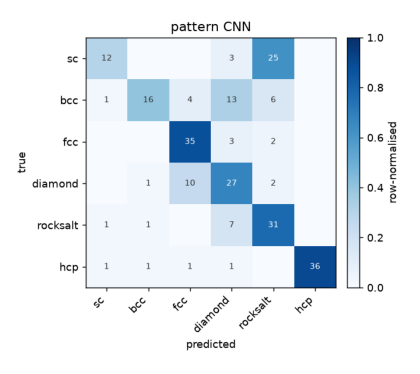

In [7]:
from crystalclass.plots import plot_confusion_matrix
import numpy as np
rep = summarize(test.labels, predict_pattern(pattern, test.images))
plot_confusion_matrix(np.array(rep['confusion_matrix']), 'tutorial_confusion.png', title='pattern CNN')
plt.figure(figsize=(5.2, 4.6)); plt.imshow(plt.imread('tutorial_confusion.png')); plt.axis('off'); plt.show()

## 7. Accuracy versus dose

The headline axis: how each method degrades as photons vanish.

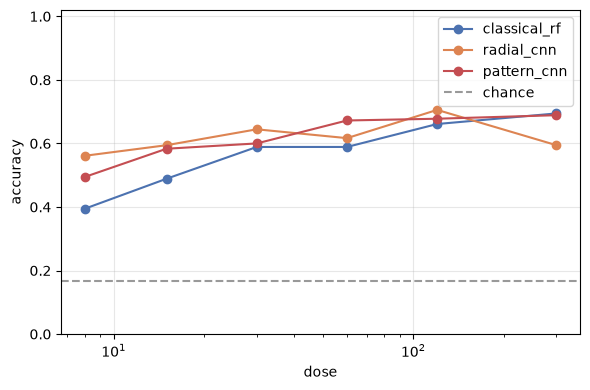

In [8]:
doses = [8, 15, 30, 60, 120, 300]
curves = {k: [] for k in acc}
for d in doses:
    ds = make_dataset(len(LABELS) * 30, seed=200 + d, base=reference_config({'dose': float(d)}))
    curves['classical_rf'].append(accuracy(ds.labels, rf.predict(ds.images)))
    curves['radial_cnn'].append(accuracy(ds.labels, predict_radial(radial, ds.profiles)))
    curves['pattern_cnn'].append(accuracy(ds.labels, predict_pattern(pattern, ds.images)))

plt.figure(figsize=(6, 4))
for k, c in zip(curves, ['#4c72b0', '#dd8452', '#c44e52']):
    plt.plot(doses, curves[k], '-o', color=c, label=k)
plt.axhline(1/len(LABELS), ls='--', color='#999', label='chance')
plt.xscale('log'); plt.xlabel('dose'); plt.ylabel('accuracy'); plt.ylim(0, 1.02); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Takeaway

The numbers here come from a small inline training run, so they are noisier than the committed benchmark in `RESULTS.md`, but the shape is the same: all methods are strong at high dose, they separate as photons and reflections vanish, and the hard confusions are diamond against FCC against rock salt. The full benchmark, with fixed seeds and larger pools, regenerates from the YAML configs in `configs/`.